# Feature engineering

The purpose of this notebook is to create a transformer to build the features to be used in training the models.

In [53]:
# Standard Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [54]:
# Load training set - for experimentation
from spacey_falcon_9_project.config import processed_dir, training_set

df = pd.read_csv(processed_dir / training_set)
df.head()

,launch_designator,booster_version,orbit,mission_type,launch_site,landing_success,landing_type,flights,reused,landing_pad,...,serial,longitude,latitude,reused_count,payload_mass,launch_date,class,nearest_highway,nearest_railway,nearest_coastline
0,2025-037,Falcon 9,Low Earth Orbit,Communications,Space Launch Complex 4E,True,ASDS,22,True,OCISLY,...,B1082,-120.611000,34.632000,10,15.500,2025-02-23,1,30.520335,1.252787,1.468531
1,2018-076,Falcon 9,Sun-Synchronous Orbit,Communications,Space Launch Complex 4E,True,RTLS,5,True,LZ-4,...,B1048,-120.611000,34.632000,1,3.000,2018-10-08,1,30.520335,1.252787,1.468531
2,2022-097,Falcon 9,Low Earth Orbit,Communications,Launch Complex 39A,True,ASDS,21,True,ASOG,...,B1073,-80.604282,28.608227,2,15.644,2022-08-10,1,22.499530,19.984845,0.544885
3,2022-094,Falcon 9,Elliptical Orbit,Lunar Exploration,Space Launch Complex 40,True,ASDS,8,True,JRTI,...,B1052,-80.577357,28.561941,5,0.678,2022-08-04,1,17.694811,21.169013,0.930777
4,2026-001,Falcon 9,Sun-Synchronous Orbit,Earth Science,Space Launch Complex 4E,True,RTLS,25,True,LZ-4,...,B1081,-120.611000,34.632000,20,2.200,2026-01-03,1,30.520335,1.252787,1.468531


In [55]:
# Retrieved selected attributes - from previous notebook
attrs = ['payload_mass', 'reused_count', 'orbit', 'mission_type', 'block', 'nearest_highway', 'nearest_railway', 'nearest_coastline']
X = df[attrs]
y = df['class']

In [56]:
X.head()

,payload_mass,reused_count,orbit,mission_type,block,nearest_highway,nearest_railway,nearest_coastline
0,15.500,10,Low Earth Orbit,Communications,Block 5,30.520335,1.252787,1.468531
1,3.000,1,Sun-Synchronous Orbit,Communications,Block 5,30.520335,1.252787,1.468531
2,15.644,2,Low Earth Orbit,Communications,Block 5,22.499530,19.984845,0.544885
3,0.678,5,Elliptical Orbit,Lunar Exploration,Block 5,17.694811,21.169013,0.930777
4,2.200,20,Sun-Synchronous Orbit,Earth Science,Block 5,30.520335,1.252787,1.468531


## Payload Mass

In [57]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2)

payload_mass = X[['payload_mass']].to_numpy()

gmm.fit(payload_mass)

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [58]:
x_dist = np.linspace(-1,20,int(1e4))
log_y_dist = gmm.score_samples(x_dist.reshape(-1,1))
y_dist = np.exp(log_y_dist.reshape(x_dist.shape))
y_dist.shape

(10000,)

In [59]:
from sklearn.metrics.pairwise import rbf_kernel

n_components = 2
centers = gmm.means_.flatten()
vars_ = gmm.covariances_.flatten()

rbf_features = []
for center, var in zip(centers, vars_):
    rbf_transform = rbf_kernel(x_dist.reshape(-1,1), [[center]], gamma=1/(n_components*var))
    rbf_features.append(rbf_transform)

y_rbf = np.hstack(rbf_features)

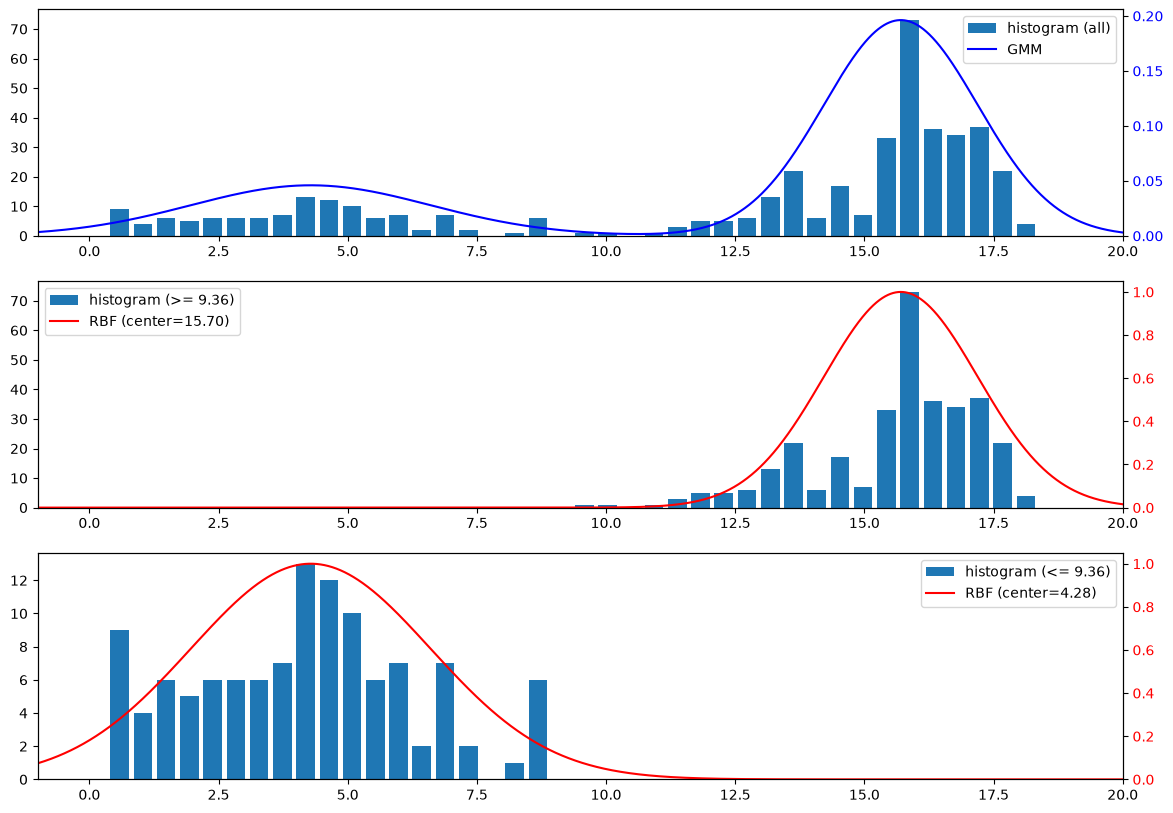

In [60]:
fig,axs = plt.subplots(3,1,figsize=(14,10))

count, bins = np.histogram(payload_mass, bins=40)
median = np.median(bins)
median_idx = np.argwhere(bins==median).item()

hists = {'histogram (all)': (bins, count),
             'histogram (>= {:.2f})'.format(median): (bins[median_idx:], count[median_idx:]),
             'histogram (<= {:.2f})'.format(median): (bins[:median_idx+1], count[:median_idx])}
data = {'GMM': (x_dist, y_dist),
       'RBF (center={:.2f})'.format(centers[0]): (x_dist, y_rbf[:,0]),
       'RBF (center={:.2f})'.format(centers[1]): (x_dist, y_rbf[:,1])}
colors = ['blue', 'red', 'red']
for hist_label, line_label, hist, data_, ax, color in zip(hists.keys(), data.keys(), hists.values(), data.values(), axs.flat, colors):
    ax.hist(hist[0][:-1], bins=hist[0], weights=hist[1], rwidth=0.8, label=hist_label)
    ax.set_xlim(-1,20)

    ax_twin = ax.twinx()
    ax_twin.plot(*data_, color=color, label=line_label)
    ax_twin.tick_params(axis='y', labelcolor=color)
    ax_twin.set_ylim(bottom=0)

    handle1, label1 = ax.get_legend_handles_labels()
    handle2, label2 = ax_twin.get_legend_handles_labels()
    ax_twin.legend(handle1+handle2, label1+label2)

plt.show()

In [61]:
from sklearn.base import BaseEstimator, TransformerMixin

class GMMRBFSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=2, random_state=None):
        self.n_components = n_components
        self.random_state = random_state
        
    def fit(self, X, y=None):
        self.gmm_ = GaussianMixture(n_components = self.n_components)
        self.gmm_.fit(X)
        self.centers_ = self.gmm_.means_
        self.gamma_ = 1 / (self.n_components * self.gmm_.covariances_)
        return self

    def transform(self, X):
        rbf_features = []
        for center, gamma in zip(self.centers_.flatten(), self.gamma_.flatten()):
            kernel = rbf_kernel(X, [[center]], gamma=gamma)
            rbf_features.append(kernel)
        return np.hstack(rbf_features)

    def get_feature_names_out(self, names=None):
        return ["Component {} similarity".format(i) for i in range(self.n_components)]

## Reused Count

In [203]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline

logtransform = FunctionTransformer(np.log1p, inverse_func=np.expm1)
scale = StandardScaler()
rc_pipeline = make_pipeline(logtransform, scale)

reused_count = X[['reused_count']].to_numpy()

log_transformed = logtransform.fit_transform(reused_count)
scaled = scale.fit_transform(log_transformed)

print(reused_count[:5])
print(scaled[:5])

[[10]
 [ 1]
 [ 2]
 [ 5]
 [20]]
[[ 0.4734091 ]
 [-1.14094072]
 [-0.75697635]
 [-0.10058493]
 [ 1.08574734]]


In [204]:
rc_pipeline.fit_transform(reused_count)[:5]

array([[ 0.4734091 ],
       [-1.14094072],
       [-0.75697635],
       [-0.10058493],
       [ 1.08574734]])

## Orbit, Mission Type

In [96]:
orbit = X['orbit']
threshold = 20
orbit_vals = orbit.value_counts()[lambda s: s < 20].index

In [97]:
orbit_con = orbit.isin(orbit_vals)
orbit.where(~orbit_con, "Others").value_counts()

orbit
Low Earth Orbit                 332
Geostationary Transfer Orbit     47
Others                           37
Sun-Synchronous Orbit            25
Name: count, dtype: int64

In [227]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=20, other_label='Others'):
        self.threshold = threshold
        self.other_label = other_label

    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_numpy()
        self.below_threshold_ = np.empty(len(self.feature_names_in_), dtype=np.ndarray)
        for i,column in enumerate(self.feature_names_in_):
            self.below_threshold_[i] = X[column].value_counts()[lambda s: s < threshold].index.to_numpy()
        return self

    def transform(self, X):
        X = X.copy()
        self.group_cond_ = np.empty(len(self.feature_names_in_), dtype=np.ndarray)
        features = []
        for i,column in enumerate(self.feature_names_in_):
            self.group_cond_[i] = X[column].isin(self.below_threshold_[i]).to_numpy()
            features.append(
                X[column].where(~self.group_cond_[i],
                                self.other_label)
            )

        if len(features)==1:
            return np.column_stack(features).reshape(-1,1)
        else:
            return np.column_stack(features)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_

In [228]:
cats_df = X[['mission_type','orbit']]

RareCategoryGrouper().fit(cats_df).transform(cats_df).shape

(441, 2)

In [229]:
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(
    [("grouper", RareCategoryGrouper(), ["orbit", "mission_type"])],
    remainder="passthrough"
)

transformer.fit(X)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('grouper', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [230]:
X_transform_np = transformer.transform(X)
columns = transformer.get_feature_names_out()

In [231]:
X_transform_df = pd.DataFrame(X_transform_np, columns=columns)
X_transform_df.head()

,grouper__orbit,grouper__mission_type,remainder__payload_mass,remainder__reused_count,remainder__block,remainder__nearest_highway,remainder__nearest_railway,remainder__nearest_coastline
0,Low Earth Orbit,Communications,15.5,10,Block 5,30.520335,1.252787,1.468531
1,Sun-Synchronous Orbit,Communications,3.0,1,Block 5,30.520335,1.252787,1.468531
2,Low Earth Orbit,Communications,15.644,2,Block 5,22.49953,19.984845,0.544885
3,Others,Others,0.678,5,Block 5,17.694811,21.169013,0.930777
4,Sun-Synchronous Orbit,Others,2.2,20,Block 5,30.520335,1.252787,1.468531


In [232]:
X_transform_df['grouper__orbit'].value_counts()

grouper__orbit
Low Earth Orbit                 332
Geostationary Transfer Orbit     47
Others                           37
Sun-Synchronous Orbit            25
Name: count, dtype: int64

In [233]:
X_transform_df['grouper__mission_type'].value_counts()

grouper__mission_type
Communications           328
Others                    61
Government/Top Secret     26
Resupply                  26
Name: count, dtype: int64

## Sample of Build Features

In [234]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   payload_mass       441 non-null    float64
 1   reused_count       441 non-null    int64  
 2   orbit              441 non-null    str    
 3   mission_type       441 non-null    str    
 4   block              441 non-null    str    
 5   nearest_highway    441 non-null    float64
 6   nearest_railway    441 non-null    float64
 7   nearest_coastline  441 non-null    float64
dtypes: float64(4), int64(1), str(3)
memory usage: 27.7 KB


In [235]:
from sklearn.preprocessing import OneHotEncoder

encode = OneHotEncoder(sparse_output=False, dtype=int) # For all cats
regroup_encode = make_pipeline(RareCategoryGrouper(), encode) # For orbit and mission_type
gmmrbf = GMMRBFSimilarity() # For payload_mass
scale = StandardScaler() # For all numericals except payload_mass
log1p_scale = make_pipeline(FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out='one-to-one'), scale) # For reused_count

transformer = ColumnTransformer(
    [
        ("regroup_encode", regroup_encode, ['orbit', 'mission_type']),
        ("encode", encode, ['block']),
        ("gmmrbf", gmmrbf, ['payload_mass']),
        ("scale", scale, ['nearest_highway', 'nearest_railway', 'nearest_coastline']),
        ("log1p_scale", log1p_scale, ['reused_count'])
    ],
)

transformer.fit(X)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('regroup_encode', ...), ('encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [236]:
X_transformed = pd.DataFrame(transformer.transform(X), columns=transformer.get_feature_names_out())

In [237]:
X_transformed

,regroup_encode__orbit_Geostationary Transfer Orbit,regroup_encode__orbit_Low Earth Orbit,regroup_encode__orbit_Others,regroup_encode__orbit_Sun-Synchronous Orbit,regroup_encode__mission_type_Communications,regroup_encode__mission_type_Government/Top Secret,regroup_encode__mission_type_Others,regroup_encode__mission_type_Resupply,encode__block_Block 5,encode__block_Legacy,gmmrbf__Component 0 similarity,gmmrbf__Component 1 similarity,scale__nearest_highway,scale__nearest_railway,scale__nearest_coastline,log1p_scale__reused_count
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9.906392e-01,8.255095e-06,1.468528,-1.536691,1.390998,0.473409
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.598542e-16,8.579886e-01,1.468528,-1.536691,1.390998,-1.140941
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9.991813e-01,6.100536e-06,0.043202,0.546973,-1.539697,-0.756976
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,7.975741e-23,2.984691e-01,-0.810614,0.678694,-0.315277,-0.100585
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.418000e-18,6.678503e-01,1.468528,-1.536691,1.390998,1.085747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,8.670261e-01,9.331624e-07,-0.810614,0.678694,-0.315277,0.473409
437,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,6.106130e-12,9.533173e-01,0.043202,0.546973,-1.539697,0.555806
438,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.067478e-01,1.015221e-08,0.043202,0.546973,-1.539697,-1.797332
439,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,8.942397e-01,2.289830e-05,-0.810614,0.678694,-0.315277,0.828234


In [238]:
from sklearn.linear_model import LogisticRegression

lr_pipe = make_pipeline(transformer, LogisticRegression())
lr_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['payload_mass','reused_count','orbit',...,'nearest_highway', 'nearest_railway','nearest_coastline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('regroup_encode', ...), ('encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defaul

In [239]:
from spacey_falcon_9_project.config import test_set

test_df = pd.read_csv(processed_dir / test_set)
X_test = test_df[attrs]
y_test = test_df['class'].to_numpy()

score = lr_pipe.score(X_test, y_test)

In [241]:
100*score

92.7927927927928

GAHH DAYUM!